Starting Section 1 visual transformation execution...


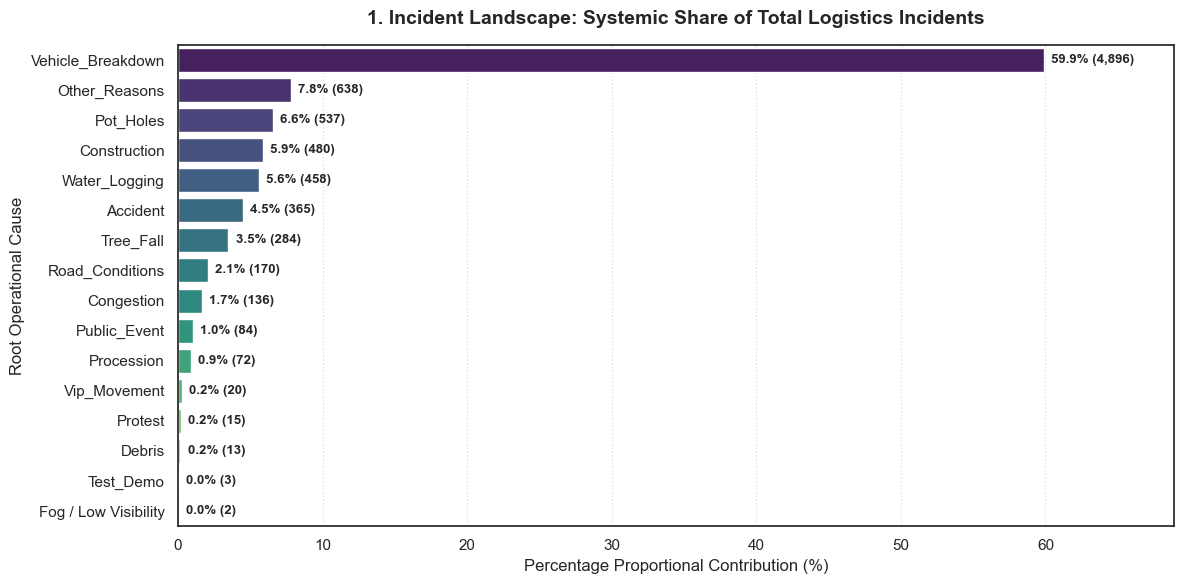

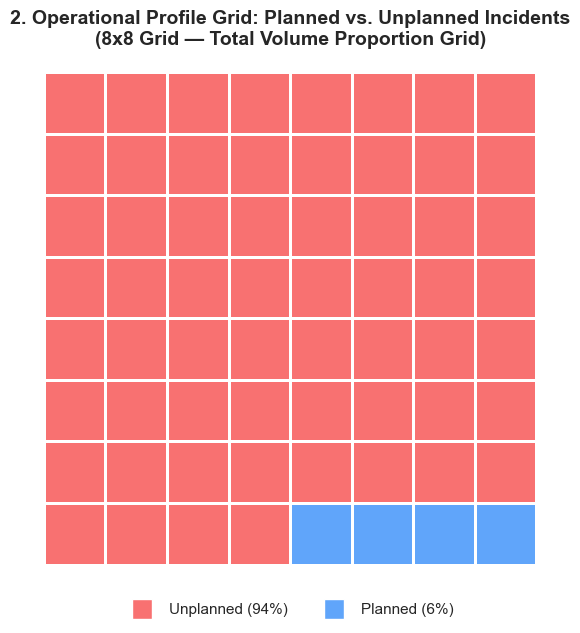

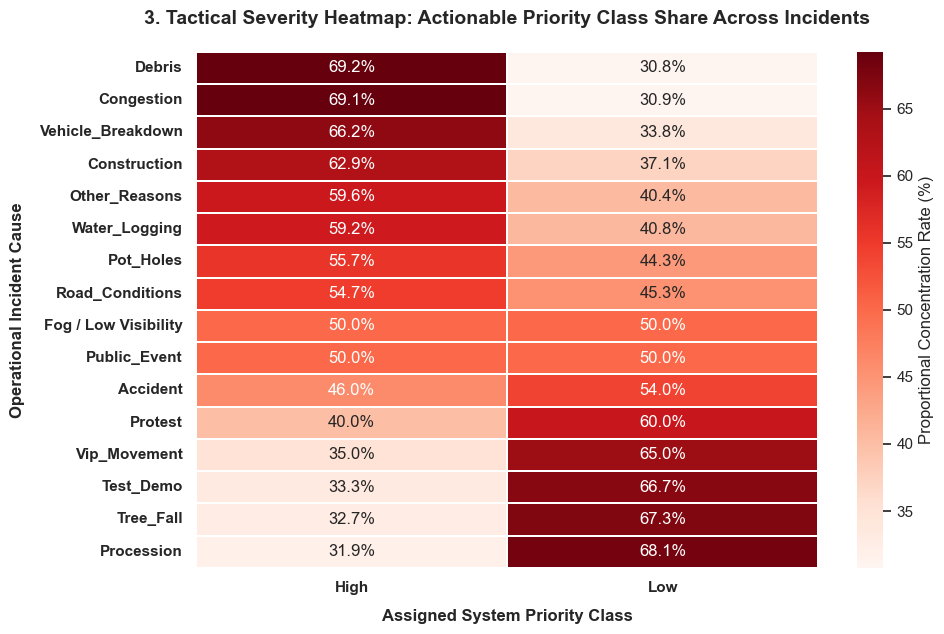

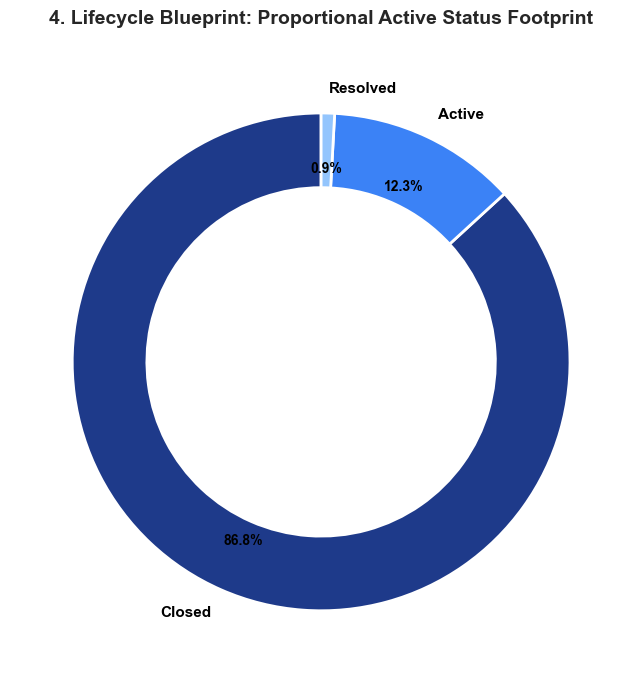

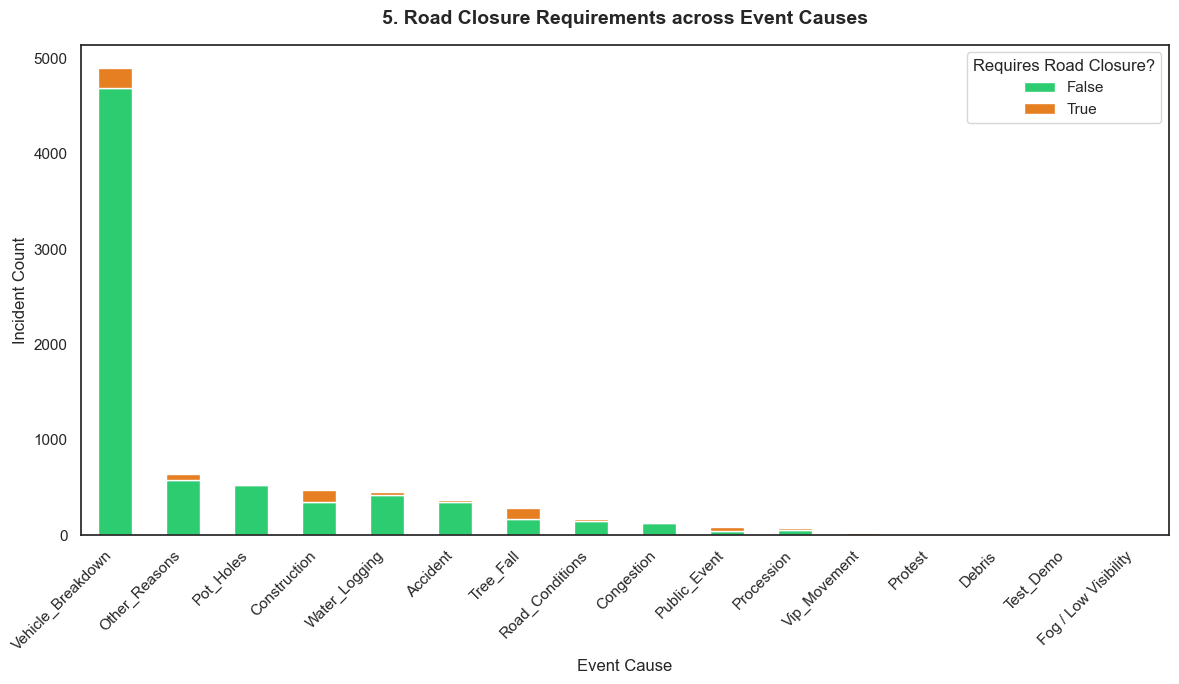

Section 1 completely upgraded and executing with total stability!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}. Check the path.")

df = pd.read_csv(file_path, low_memory=False)

categorical_cols = ['event_type', 'event_cause', 'priority', 'status', 'requires_road_closure']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

df['event_cause'] = df['event_cause'].replace({'NAN': 'UNKNOWN', 'OTHERS': 'OTHER_REASONS'}).str.title()
df['priority'] = df['priority'].replace({'NAN': 'UNKNOWN'}).str.title()
df['status'] = df['status'].replace({'NAN': 'UNKNOWN'}).str.title()
df['requires_road_closure'] = df['requires_road_closure'].replace({'TRUE': 'True', 'FALSE': 'False', 'NAN': 'Unknown'})

sns.set_theme(style="white")
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif'
})

print("Starting Section 1 visual transformation execution...")

# CHART 1: EVENT CAUSE DISTRIBUTION (TREEMAP ALTERNATIVE)
plt.figure(figsize=(12, 6))
cause_counts = df['event_cause'].value_counts()
cause_pcts = (cause_counts / len(df)) * 100

sns.barplot(x=cause_pcts.values, y=cause_pcts.index, hue=cause_pcts.index, palette="viridis", legend=False)
plt.title("1. Incident Landscape: Systemic Share of Total Logistics Incidents", weight='bold', pad=15)
plt.xlabel("Percentage Proportional Contribution (%)")
plt.ylabel("Root Operational Cause")

for idx, val in enumerate(cause_pcts.values):
    plt.text(val + 0.5, idx, f"{val:.1f}% ({cause_counts.values[idx]:,})", va='center', ha='left', fontsize=9.5, weight='bold')

plt.xlim(0, cause_pcts.max() * 1.15)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("charts/chart_1_operational_share.png", dpi=300)
plt.show()

# CHART 2: PLANNED VS UNPLANNED (8x8 WAFFLE GRID MATRIX)
type_counts = df['event_type'].value_counts()
if 'NAN' in type_counts.index:
    type_counts = type_counts.drop('NAN')

type_pcts = (type_counts / type_counts.sum() * 100).round().astype(int)

total_blocks = 64
type_blocks = (type_counts / type_counts.sum() * total_blocks).round().astype(int)

waffle_grid = np.zeros((8, 8))
current_idx = 0
category_labels = list(type_pcts.index)

for cat_idx, cat_name in enumerate(category_labels):
    blocks_count = type_blocks[cat_name]
    
    if cat_idx == len(category_labels) - 1:
        blocks_count = total_blocks - current_idx
    
    for _ in range(int(blocks_count)):
        row = current_idx // 8
        col = current_idx % 8
        waffle_grid[row, col] = cat_idx + 1
        current_idx += 1

fig, ax = plt.subplots(figsize=(6.5, 6.5))

waffle_colors = ['#f87171', '#60a5fa', '#34d399']
sns.heatmap(
    waffle_grid, 
    cmap=waffle_colors[:len(type_pcts)], 
    cbar=False, 
    annot=False, 
    linewidths=2, 
    linecolor='white', 
    square=True, 
    ax=ax
)

ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=waffle_colors[i], markersize=14, 
               label=f"{lbl.title()} ({type_pcts[lbl]}%)") 
    for i, lbl in enumerate(category_labels)
]
plt.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=11)

plt.title("2. Operational Profile Grid: Planned vs. Unplanned Incidents\n(8x8 Grid — Total Volume Proportion Grid)", weight='bold', pad=20)
plt.tight_layout()
plt.savefig("charts/chart_2_waffle_profile_8x8.png", dpi=300)
plt.show()

# CHART 3: PRIORITY BY CAUSE SEVERITY RATIO (HEATMAP SEVERITY)
plt.figure(figsize=(10, 6.5))

severity_matrix = pd.crosstab(df['event_cause'], df['priority'])

if 'Unknown' in severity_matrix.columns:
    severity_matrix = severity_matrix.drop(columns=['Unknown'])
if 'Unknown' in severity_matrix.index:
    severity_matrix = severity_matrix.drop(index=['Unknown'])

severity_matrix = severity_matrix.div(severity_matrix.sum(axis=1), axis=0) * 100

if 'High' in severity_matrix.columns:
    severity_matrix = severity_matrix.sort_values(by='High', ascending=False)

sns.heatmap(
    severity_matrix, 
    cmap="Reds", 
    annot=True, 
    fmt=".1f", 
    linewidths=1.2, 
    linecolor='white', 
    cbar_kws={'label': 'Proportional Concentration Rate (%)'}, 
    square=False
)

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")

plt.title("3. Tactical Severity Heatmap: Actionable Priority Class Share Across Incidents", weight='bold', pad=20)
plt.xlabel("Assigned System Priority Class", weight='bold', labelpad=10)
plt.ylabel("Operational Incident Cause", weight='bold', labelpad=10)
plt.xticks(weight='bold')
plt.yticks(weight='bold')

plt.tight_layout()
plt.savefig("charts/chart_3_severity_heatmap.png", dpi=300)
plt.show()
# CHART 4: STATUS LIFECYCLE BREAKDOWN (RADIAL DONUT LAYOUT)
fig, ax = plt.subplots(figsize=(7, 7))
status_counts = df['status'].value_counts()

outer_colors = ['#1e3a8a', '#3b82f6', '#93c5fd', '#cbd5e1']
wedges, texts, autotexts = ax.pie(
    status_counts.values, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=outer_colors[:len(status_counts)],
    pctdistance=0.78,
    textprops=dict(color="#000000", weight="bold"),
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=2)
)

plt.setp(autotexts, size=10, weight="bold")
plt.title("4. Lifecycle Blueprint: Proportional Active Status Footprint", weight='bold', pad=20)
plt.tight_layout()
plt.savefig("charts/chart_4_status_donut.png", dpi=300)
plt.show()


# Chart 5: Road Closure Requirement by Event Cause (Stacked Bar)
plt.figure(figsize=(12, 7))
closure_cause_df = pd.crosstab(df['event_cause'], df['requires_road_closure'])
closure_cause_df = closure_cause_df.loc[closure_cause_df.sum(axis=1).sort_values(ascending=False).index]

closure_cause_df.plot(kind='bar', stacked=True, color=['#2ecc71', '#e67e22', '#7f8c8d'], ax=plt.gca())
plt.title("5. Road Closure Requirements across Event Causes", weight='bold', pad=15)
plt.xlabel("Event Cause")
plt.ylabel("Incident Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Requires Road Closure?")
plt.tight_layout()
plt.savefig("charts/chart_5_road_closure_by_cause.png", dpi=300)
plt.show()


print("Section 1 completely upgraded and executing with total stability!")

Executing upgraded Section 2 temporal blueprint...


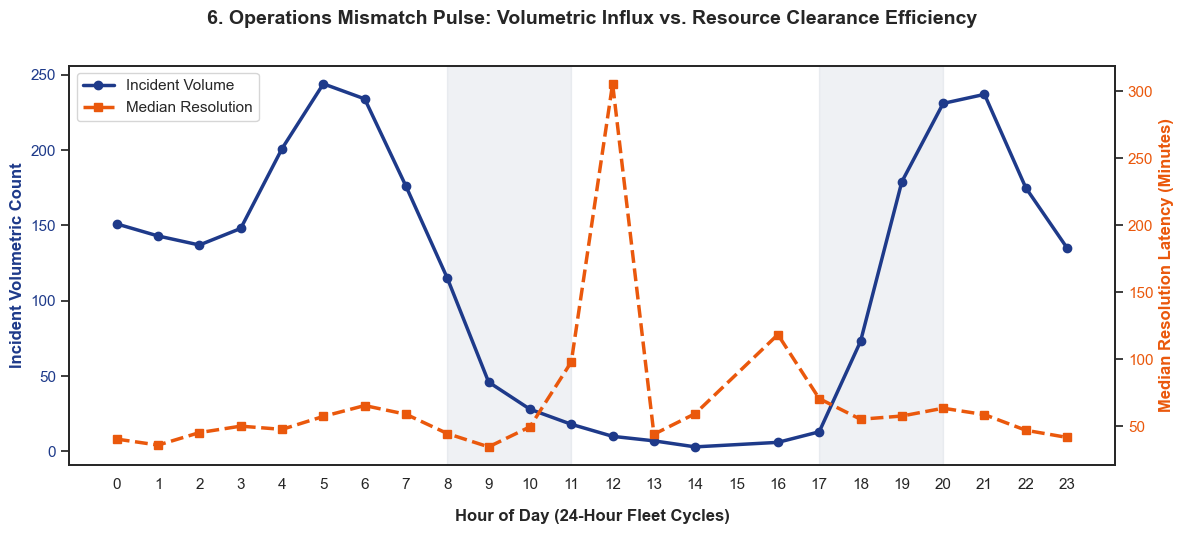

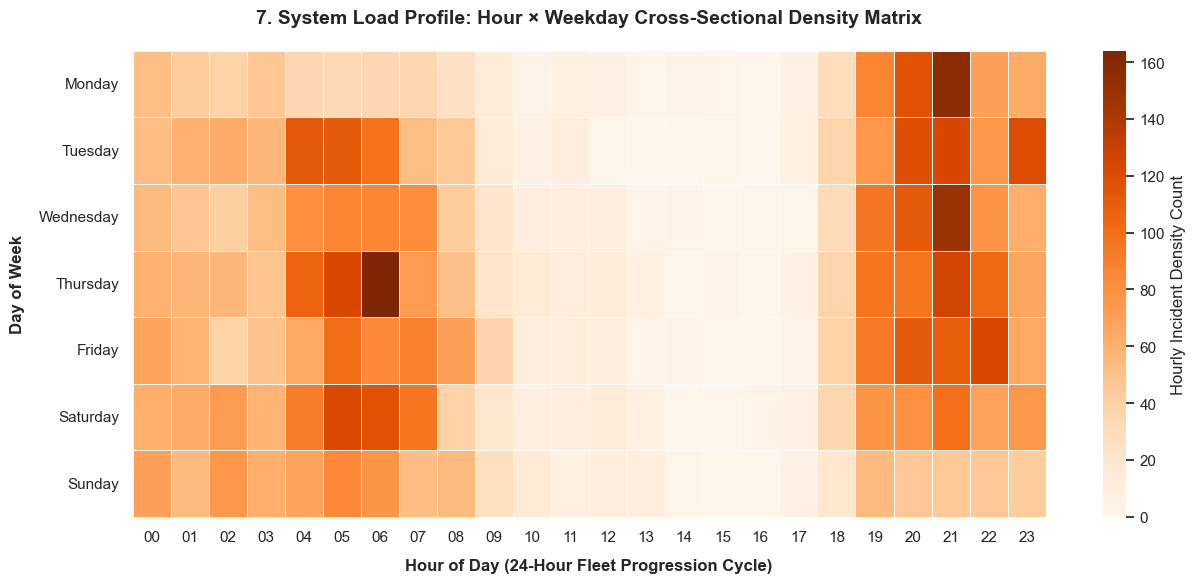

C:\Users\HP\AppData\Local\Temp\ipykernel_3580\1744270392.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_metrics['month'], rotation=30, ha='right')


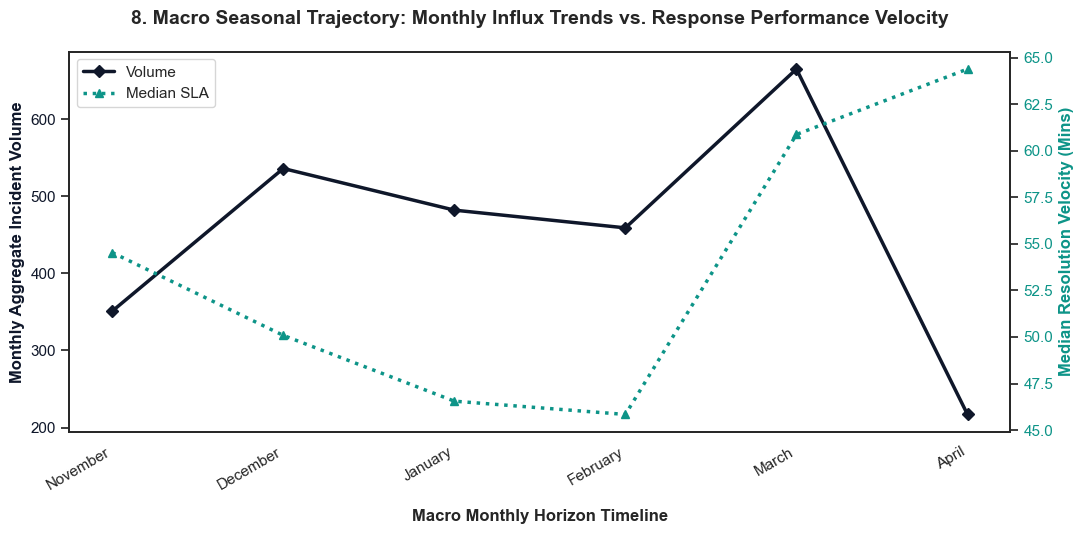

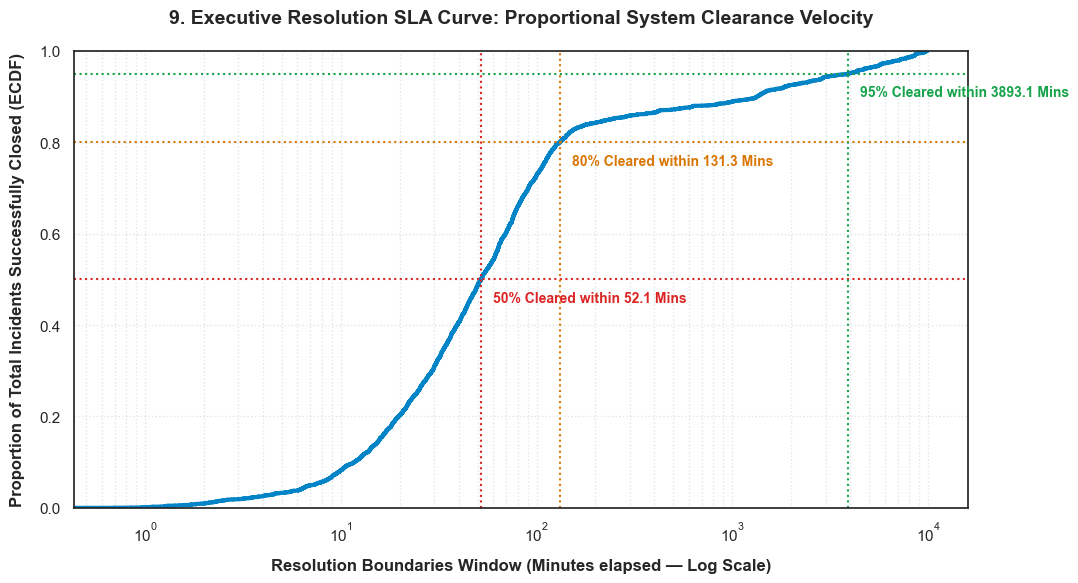

Section 2 completely re-engineered into an advanced temporal dashboard portfolio!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif'
})

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}. Check the path.")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['start_datetime_dt'])

df['hour'] = df['start_datetime_dt'].dt.hour
df['day_of_week'] = df['start_datetime_dt'].dt.day_name()
df['month'] = df['start_datetime_dt'].dt.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

df['resolution_mins'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0
df_resolved = df[(df['resolution_mins'] > 0) & (df['resolution_mins'] < 10000)].copy()

print("Executing upgraded Section 2 temporal blueprint...")


# CHART 6: HOURLY OPERATIONS PULSE (DUAL-AXIS PROFILED)
hourly_metrics = df_resolved.groupby('hour').agg(
    incident_count=('hour', 'size'),
    median_resolution=('resolution_mins', 'median')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5.5))

color_vol = '#1e3a8a'
ax1.set_xlabel('Hour of Day (24-Hour Fleet Cycles)', weight='bold', labelpad=12)
ax1.set_ylabel('Incident Volumetric Count', color=color_vol, weight='bold')

line1 = ax1.plot(hourly_metrics['hour'], hourly_metrics['incident_count'], 
                 marker='o', color=color_vol, linewidth=2.5, label='Incident Volume')
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
color_res = '#ea580c'
ax2.set_ylabel('Median Resolution Latency (Minutes)', color=color_res, weight='bold')
line2 = ax2.plot(hourly_metrics['hour'], hourly_metrics['median_resolution'], 
                 marker='s', linestyle='--', color=color_res, linewidth=2.5, label='Median Resolution')
ax2.tick_params(axis='y', labelcolor=color_res)

ax1.axvspan(8, 11, color="#94a3b8", alpha=0.15, label='Morning Commute Peak')
ax1.axvspan(17, 20, color='#94a3b8', alpha=0.15, label='Evening Commute Peak')

lines = line1 + line2
labels = [l.get_label() for l in lines]

# FIXED: Removed bbox_to_anchor to match the exact placement, size, and style of Chart 8
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title("6. Operations Mismatch Pulse: Volumetric Influx vs. Resource Clearance Efficiency", weight='bold', pad=30)
plt.tight_layout()
plt.savefig("charts/chart_6_dual_axis_pulse.png", dpi=300)
plt.show()


# CHART 7: CHRONOLOGICAL PROFILE (WEEKDAY X HOUR HEATMAP) - FIXED AXIS & PALETTE
plt.figure(figsize=(13, 6))

density_matrix = pd.crosstab(df['day_of_week'], df['hour'])

density_matrix = density_matrix.reindex(columns=range(0, 24), fill_value=0)

sns.heatmap(
    density_matrix, 
    cmap="Oranges", 
    cbar_kws={'label': 'Hourly Incident Density Count'},
    linewidths=0.5, 
    linecolor='#f8fafc'
)

plt.title("7. System Load Profile: Hour × Weekday Cross-Sectional Density Matrix", weight='bold', pad=20)
plt.xlabel("Hour of Day (24-Hour Fleet Progression Cycle)", weight='bold', labelpad=10)
plt.ylabel("Day of Week", weight='bold', labelpad=10)

plt.xticks(
    ticks=np.arange(0.5, 24.5, 1),
    labels=[f"{h:02d}" for h in range(0, 24)],
    rotation=0
)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("charts/chart_7_temporal_heatmap.png", dpi=300)
plt.show()

# CHART 8: MONTHLY MACRO DYNAMICS (EFFICIENCY TREND LINE)
present_months = [m for m in ['November', 'December','January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October'] if m in df_resolved['month'].unique()]
df_resolved['month'] = pd.Categorical(df_resolved['month'], categories=present_months, ordered=True)

monthly_metrics = df_resolved.groupby('month', observed=False).agg(
    incidents=('resolution_mins', 'size'),
    median_res=('resolution_mins', 'median')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5.5))

color_m1 = '#0f172a'
ax1.set_xlabel('Macro Monthly Horizon Timeline', weight='bold', labelpad=12)
ax1.set_ylabel('Monthly Aggregate Incident Volume', color=color_m1, weight='bold')
l1 = ax1.plot(monthly_metrics['month'], monthly_metrics['incidents'], marker='D', color=color_m1, linewidth=2.5, label='Volume')
ax1.tick_params(axis='y', labelcolor=color_m1)
ax1.set_xticklabels(monthly_metrics['month'], rotation=30, ha='right')

ax2 = ax1.twinx()
color_m2 = '#0d9488'
ax2.set_ylabel('Median Resolution Velocity (Mins)', color=color_m2, weight='bold')
l2 = ax2.plot(monthly_metrics['month'], monthly_metrics['median_res'], marker='^', linestyle=':', color=color_m2, linewidth=2.5, label='Median SLA')
ax2.tick_params(axis='y', labelcolor=color_m2)

lines_m = l1 + l2
labels_m = [l.get_label() for l in lines_m]
ax1.legend(lines_m, labels_m, loc='upper left')

plt.title("8. Macro Seasonal Trajectory: Monthly Influx Trends vs. Response Performance Velocity", weight='bold', pad=20)
plt.tight_layout()
plt.savefig("charts/chart_8_monthly_macro_trend.png", dpi=300)
plt.show()

# CHART 9: CLEARANCE SLA CURVE (EMBEDDED ECDF BLUEPRINT)
plt.figure(figsize=(11, 6))

sns.ecdfplot(data=df_resolved, x='resolution_mins', color='#0284c7', linewidth=3)

p50 = df_resolved['resolution_mins'].quantile(0.50)
p80 = df_resolved['resolution_mins'].quantile(0.80)
p95 = df_resolved['resolution_mins'].quantile(0.95)

plt.axvline(p50, color='#dc2626', linestyle=':', linewidth=1.5)
plt.axhline(0.50, color='#dc2626', linestyle=':', linewidth=1.5)
plt.text(p50 * 1.15, 0.45, f"50% Cleared within {p50:.1f} Mins", color='#dc2626', weight='bold', fontsize=10)

plt.axvline(p80, color='#d97706', linestyle=':', linewidth=1.5)
plt.axhline(0.80, color='#d97706', linestyle=':', linewidth=1.5)
plt.text(p80 * 1.15, 0.75, f"80% Cleared within {p80:.1f} Mins", color='#d97706', weight='bold', fontsize=10)

plt.axvline(p95, color='#16a34a', linestyle=':', linewidth=1.5)
plt.axhline(0.95, color='#16a34a', linestyle=':', linewidth=1.5)
plt.text(p95 * 1.15, 0.90, f"95% Cleared within {p95:.1f} Mins", color='#16a34a', weight='bold', fontsize=10)

plt.xscale('log')
plt.title("9. Executive Resolution SLA Curve: Proportional System Clearance Velocity", weight='bold', pad=20)
plt.xlabel("Resolution Boundaries Window (Minutes elapsed — Log Scale)", weight='bold', labelpad=10)
plt.ylabel("Proportion of Total Incidents Successfully Closed (ECDF)", weight='bold', labelpad=10)
plt.grid(True, which="both", linestyle=':', color='#cbd5e1', alpha=0.6)

plt.tight_layout()
plt.savefig("charts/chart_9_sla_cumulative_curve.png", dpi=300)
plt.show()

print("Section 2 completely re-engineered into an advanced temporal dashboard portfolio!")

Building interactive geospatial incident dashboard...


Success! Map generation complete. Standalone asset saved as 'bengaluru_traffic_incident_map.html'.


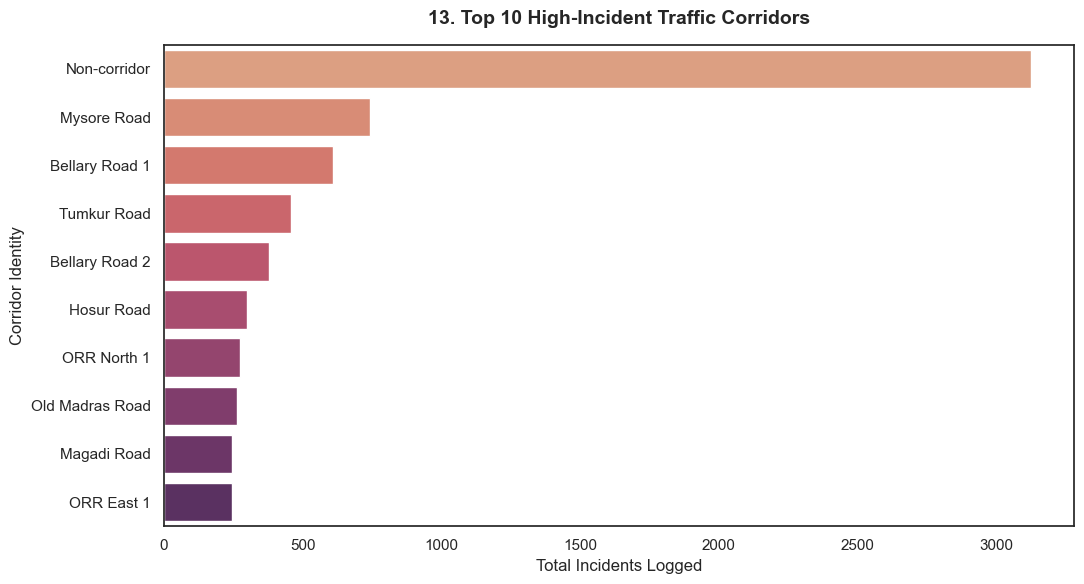

Section 3 complete! Interactive maps and fixed charts generated cleanly.


In [3]:
import os
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset path could not be resolved at: {file_path}")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['resolution_mins'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0

df_geo = df.dropna(subset=['latitude', 'longitude']).copy()

map_center = [df_geo['latitude'].median(), df_geo['longitude'].median()]

print("Building interactive geospatial incident dashboard...")

map_dashboard = folium.Map(
    location=map_center, 
    zoom_start=12, 
    tiles="OpenStreetMap",
    control_scale=True
)

# LAYER 1: INCIDENT FREQUENCY HEATMAP
fg_volume_heatmap = folium.FeatureGroup(name="🔥 Incident Density Heatmap (Volume)", overlay=True, control=True)

vol_heat_data = df_geo[['latitude', 'longitude']].dropna().values.tolist()
HeatMap(
    data=vol_heat_data, 
    radius=15, 
    blur=10, 
    min_opacity=0.4
).add_to(fg_volume_heatmap)

fg_volume_heatmap.add_to(map_dashboard)


# LAYER 2: RESOLUTION TIME LATENCY HEATMAP
fg_severity_heatmap = folium.FeatureGroup(name="⚠️ Delay Severity Heatmap (Resolution Time Weighted)", overlay=True, control=True)

df_severity = df_geo[(df_geo['resolution_mins'] > 0) & (df_geo['resolution_mins'] < 10000)].dropna(subset=['latitude', 'longitude', 'resolution_mins'])

# Cap extreme duration outliers at the 95th percentile to keep the visual scale balanced
max_res = df_severity['resolution_mins'].quantile(0.95)
df_severity['normalized_weight'] = df_severity['resolution_mins'].clip(upper=max_res) / max_res

severity_heat_data = df_severity[['latitude', 'longitude', 'normalized_weight']].values.tolist()

HeatMap(
    data=severity_heat_data,
    radius=18,
    blur=12,
    min_opacity=0.3,
    gradient={0.2: 'blue', 0.4: 'green', 0.6: 'yellow', 0.8: 'orange', 1.0: 'crimson'} 
).add_to(fg_severity_heatmap)

fg_severity_heatmap.add_to(map_dashboard)


# LAYER 3: PLANNED INCIDENTS & DISRUPTIONS
fg_planned_events = folium.FeatureGroup(name="📅 Planned Events (Clustered Icons)", overlay=True, control=True)

df_planned = df_geo[df_geo['event_type'].astype(str).str.strip().str.lower() == 'planned'].copy()

marker_cluster = MarkerCluster(options={'maxClusterRadius': 40}).add_to(fg_planned_events)

color_map = {
    'public_event': 'blue',
    'vip_movement': 'purple',
    'road_works': 'orange',
    'parade': 'darkgreen',
    'protest': 'red'
}

for idx, row in df_planned.iterrows():
    cause = str(row['event_cause']).strip().lower()
    marker_color = color_map.get(cause, 'cadetblue') 
    
    popup_text = f"""
    <div style='font-family: sans-serif; font-size: 12px; width: 200px;'>
        <b style='color:#1e3a8a; font-size:13px;'>{str(row['event_cause']).title()}</b><br>
        <hr style='margin: 5px 0; border: 0; border-top: 1px solid #e2e8f0;'>
        <strong>Location:</strong> {row.get('corridor', 'N/A')}<br>
        <strong>Station:</strong> {row.get('police_station', 'N/A')}<br>
        <strong>Clearance Time:</strong> {row['resolution_mins']:.1f} mins<br>
    </div>
    """
    
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=marker_color, icon='info-sign'),
        tooltip=f"Planned: {row['event_cause']}"
    ).add_to(marker_cluster)

fg_planned_events.add_to(map_dashboard)


folium.LayerControl(position='topright', collapsed=False).add_to(map_dashboard)

output_filename = "bengaluru_traffic_incident_map.html"
map_dashboard.save(output_filename)

print(f"Success! Map generation complete. Standalone asset saved as '{output_filename}'.")


# Chart 13: Top 10 Corridors by Event Count (Horizontal Bar Chart)
plt.figure(figsize=(11, 6))
df_geo['corridor'] = df_geo['corridor'].fillna('Unknown / Non-Corridor Framework')
top_corridors = df_geo['corridor'].value_counts().head(10)

sns.barplot(x=top_corridors.values, y=top_corridors.index, hue=top_corridors.index, palette="flare", legend=False)
plt.title("13. Top 10 High-Incident Traffic Corridors", weight='bold', pad=15)
plt.xlabel("Total Incidents Logged")
plt.ylabel("Corridor Identity")
plt.tight_layout()
plt.savefig("charts/chart_13_top_corridors.png", dpi=300)
plt.show()



print("Section 3 complete! Interactive maps and fixed charts generated cleanly.")

Generating Visualization B: Incident Patterns Across the Day...


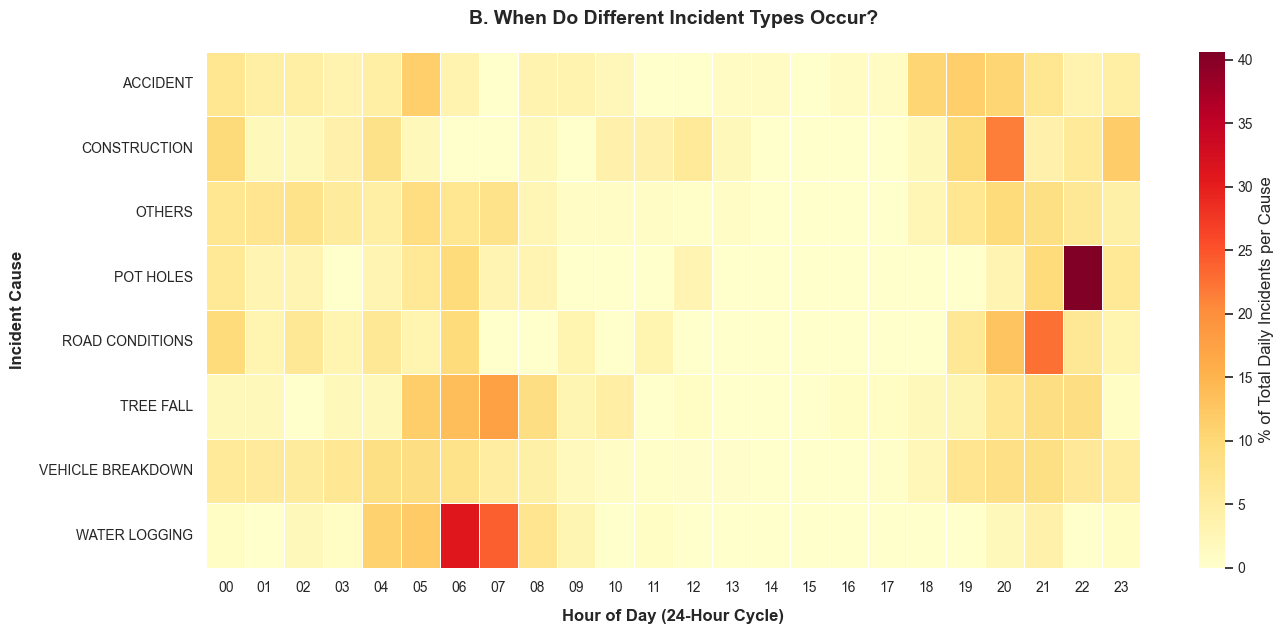

Generating Visualization G: Most Impacted Junctions...


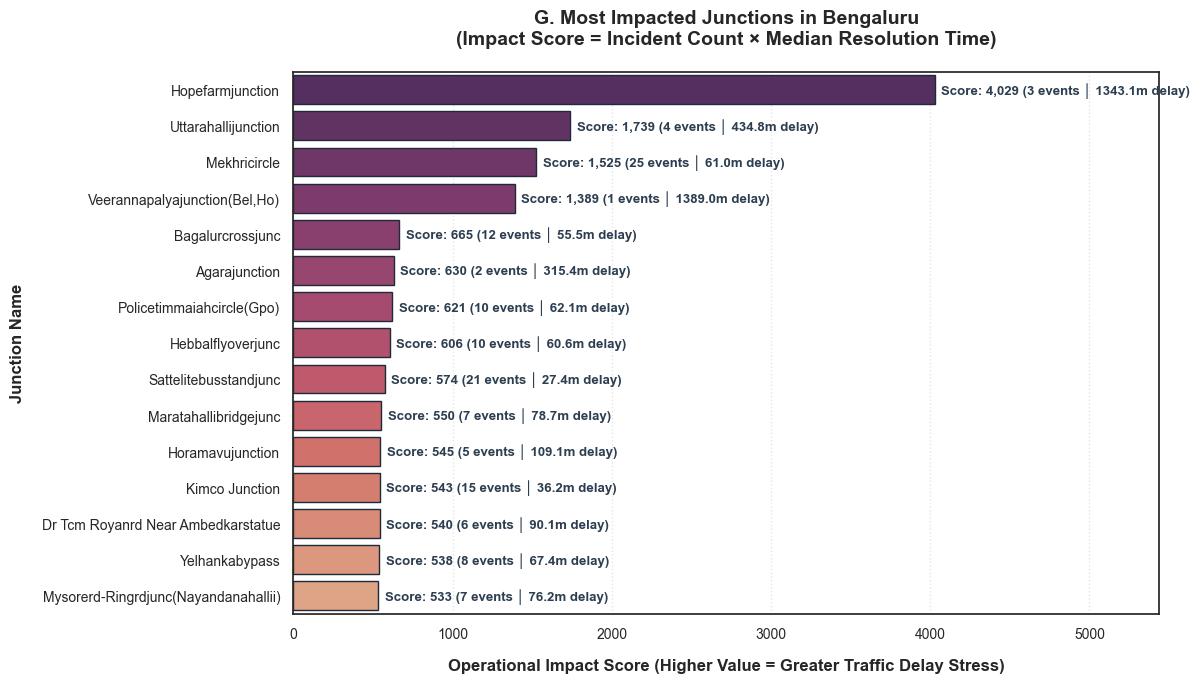

Execution complete! Simplified, presentation-ready assets saved successfully.


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif'
})

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}. Check the path.")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['resolution_mins'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0

df['hour'] = df['start_datetime_dt'].dt.hour
df['incident_cause'] = df['event_cause'].fillna('UNKNOWN').astype(str).str.strip().str.upper().str.replace('_', ' ')
df['corridor_name'] = df['corridor'].fillna('NON-CORRIDOR').astype(str).str.strip().str.upper()
df['junction_name'] = df['junction'].fillna('UNKNOWN JUNCTION').astype(str).str.strip().str.upper()

if 'priority' in df.columns:
    df['is_high_priority'] = df['priority'].astype(str).str.strip().str.upper().isin(['HIGH', 'CRITICAL', 'TRUE', '1'])
else:
    df['is_high_priority'] = df['requires_road_closure'].astype(str).str.strip().str.upper() == 'TRUE'

df_filtered = df[(df['resolution_mins'] > 0) & (df['resolution_mins'] < 1440)].dropna(subset=['start_datetime_dt']).copy()


# VISUALIZATION B: CAUSE × HOUR PROFILE MATRIX (NORMALIZED)
print("Generating Visualization B: Incident Patterns Across the Day...")
plt.figure(figsize=(14, 6.5))

top_causes = df_filtered['incident_cause'].value_counts().head(8).index
df_b = df_filtered[df_filtered['incident_cause'].isin(top_causes)]

cause_hour_matrix = pd.crosstab(df_b['incident_cause'], df_b['hour'])
cause_hour_matrix = cause_hour_matrix.reindex(columns=range(0, 24), fill_value=0)

cause_hour_matrix = cause_hour_matrix.div(cause_hour_matrix.sum(axis=1), axis=0) * 100

# Plot horizontal visual profile using a clean sequential colormap
sns.heatmap(
    cause_hour_matrix, 
    cmap="YlOrRd", 
    cbar_kws={'label': '% of Total Daily Incidents per Cause'}, 
    linewidths=0.5, 
    linecolor='#ffffff'
)

plt.title("B. When Do Different Incident Types Occur?", weight='bold', pad=20)
plt.xlabel("Hour of Day (24-Hour Cycle)", weight='bold', labelpad=10)
plt.ylabel("Incident Cause", weight='bold', labelpad=10)

plt.xticks(ticks=np.arange(0.5, 24.5, 1), labels=[f"{h:02d}" for h in range(0, 24)], rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/visual_b_incident_hourly_patterns.png", dpi=300)
plt.show()


# VISUALIZATION G: JUNCTION HOTSPOT RANKING (IMPACT INDEX)
print("Generating Visualization G: Most Impacted Junctions...")
plt.figure(figsize=(12, 7))

junction_stats = df_filtered.groupby('junction_name').agg(
    incident_count=('resolution_mins', 'count'),
    median_resolution=('resolution_mins', 'median')
).reset_index()

junction_stats = junction_stats[junction_stats['junction_name'] != 'UNKNOWN JUNCTION']

junction_stats['impact_score'] = junction_stats['incident_count'] * junction_stats['median_resolution']

top_15_junctions = junction_stats.sort_values(by='impact_score', ascending=False).head(15)
top_15_junctions['junction_name'] = top_15_junctions['junction_name'].str.title()

# Render horizontal visualization sequence
sns.barplot(
    data=top_15_junctions, 
    x='impact_score', 
    y='junction_name', 
    hue='junction_name', 
    palette='flare_r', 
    legend=False,
    edgecolor='#1e293b',
    linewidth=1
)

for idx, row in top_15_junctions.reset_index(drop=True).iterrows():
    plt.text(
        row['impact_score'] + (top_15_junctions['impact_score'].max() * 0.01), idx, 
        f"Score: {int(row['impact_score']):,} ({int(row['incident_count'])} events │ {row['median_resolution']:.1f}m delay)", 
        va='center', ha='left', fontsize=9.5, weight='bold', color='#2c3e50'
    )

plt.title("G. Most Impacted Junctions in Bengaluru\n(Impact Score = Incident Count × Median Resolution Time)", weight='bold', pad=20)
plt.xlabel("Operational Impact Score (Higher Value = Greater Traffic Delay Stress)", weight='bold', labelpad=12)
plt.ylabel("Junction Name", weight='bold', labelpad=12)
plt.xlim(0, top_15_junctions['impact_score'].max() * 1.35) 
plt.grid(True, axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("charts/visual_g_top_impacted_junctions.png", dpi=300)
plt.show()

print("Execution complete! Simplified, presentation-ready assets saved successfully.")

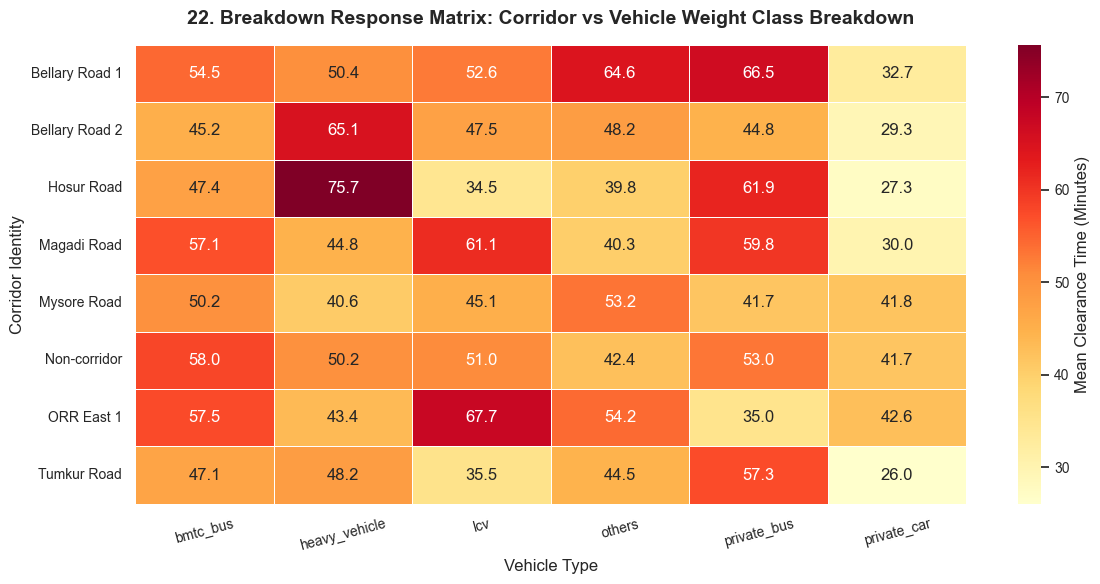

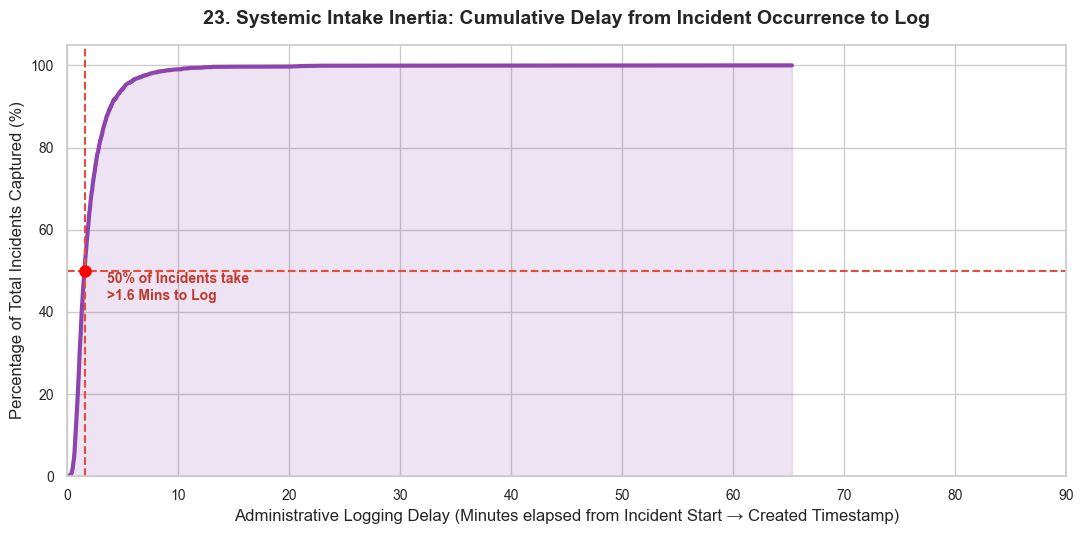

C:\Users\HP\AppData\Local\Temp\ipykernel_3580\174550997.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right')


<Figure size 1200x600 with 0 Axes>

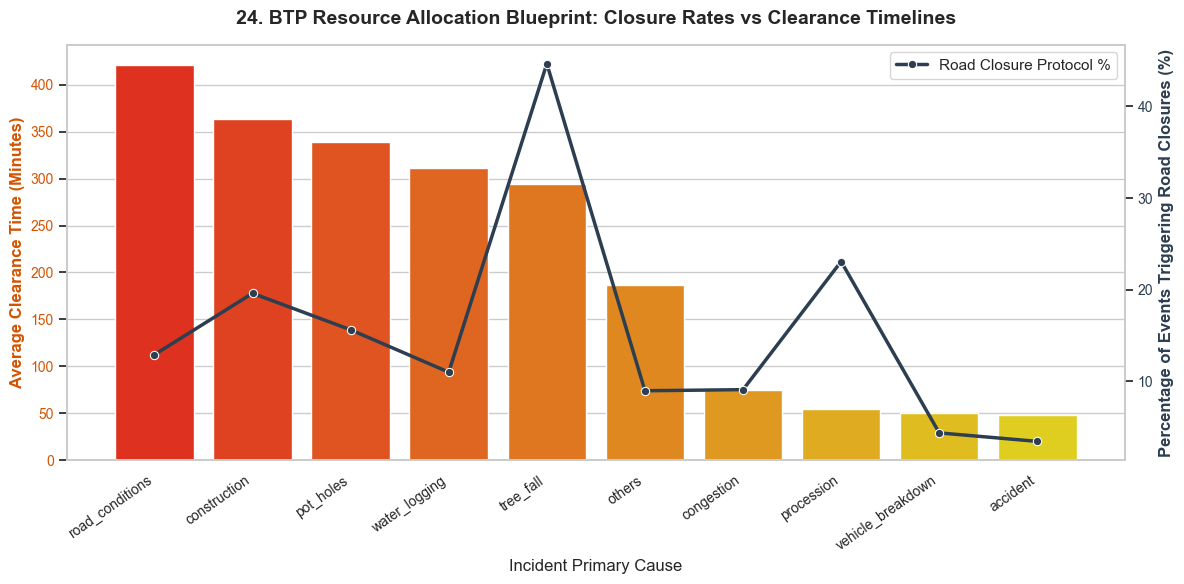

All 5 advanced strategic visualizations processed and saved cleanly as presentation-ready high-resolution assets!


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (11, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

file_path = r"theme2.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}. Check the path.")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['created_date_dt'] = pd.to_datetime(df['created_date'], utc=True, errors='coerce')

df['resolution_mins'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0
df['logging_lag_mins'] = (df['created_date_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0
df['lead_time_days'] = (df['start_datetime_dt'] - df['created_date_dt']).dt.total_seconds() / (24.0 * 3600.0)

# Filter for realistic resolution timeline boundaries (< 24 hours) for visual consistency
df_filtered = df[(df['resolution_mins'] > 0) & (df['resolution_mins'] < 1440)].copy()

df_filtered['corridor'] = df_filtered['corridor'].fillna('Non-Corridor Framework').astype(str).str.strip()
df_filtered['veh_type'] = df_filtered['veh_type'].fillna('unknown').astype(str).str.strip().str.lower()
df_filtered['police_station'] = df_filtered['police_station'].fillna('Unknown Jurisdiction').astype(str).str.strip()
df_filtered['event_cause'] = df_filtered['event_cause'].fillna('unknown').astype(str).str.strip().str.lower()
df_filtered['requires_road_closure'] = df_filtered['requires_road_closure'].astype(str).str.strip().str.upper()



# Chart 22: Vehicle Breakdown Corridor Heatmap Matrix
plt.figure(figsize=(12, 6))

df_breakdowns = df_filtered[df_filtered['event_cause'] == 'vehicle_breakdown'].copy()

top_corr_list = df_breakdowns['corridor'].value_counts().head(8).index
top_veh_list = df_breakdowns['veh_type'].value_counts().head(6).index

df_matrix_subset = df_breakdowns[df_breakdowns['corridor'].isin(top_corr_list) & df_breakdowns['veh_type'].isin(top_veh_list)]

pivot_table = df_matrix_subset.pivot_table(values='resolution_mins', index='corridor', columns='veh_type', aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Mean Clearance Time (Minutes)'})
plt.title("22. Breakdown Response Matrix: Corridor vs Vehicle Weight Class Breakdown", weight='bold', pad=15)
plt.xlabel("Vehicle Type")
plt.ylabel("Corridor Identity")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("charts/chart_22_breakdown_heatmap.png", dpi=300)
plt.show()


# Chart 23: Logging Lag Distribution Analysis
plt.figure(figsize=(11, 5.5))

df_lag = df_filtered[(df_filtered['logging_lag_mins'] >= 0) & (df_filtered['logging_lag_mins'] <= 120)].copy()

sorted_lag = np.sort(df_lag['logging_lag_mins'])
cumulative_percentage = np.arange(1, len(sorted_lag) + 1) / len(sorted_lag) * 100

plt.plot(sorted_lag, cumulative_percentage, color='#8e44ad', linewidth=3, label='Cumulative Intake Rate')
plt.fill_between(sorted_lag, cumulative_percentage, color='#8e44ad', alpha=0.15)

median_lag = df_lag['logging_lag_mins'].median()
p75_lag = np.percentile(df_lag['logging_lag_mins'], 75)

plt.axvline(median_lag, color='#e74c3c', linestyle='--', linewidth=1.5)
plt.axhline(50, color='#e74c3c', linestyle='--', linewidth=1.5)
plt.plot(median_lag, 50, marker="o", color="red", markersize=8)
plt.text(median_lag + 2, 43, f"50% of Incidents take\n>{median_lag:.1f} Mins to Log", color='#c0392b', weight='bold', fontsize=10)

plt.title("23. Systemic Intake Inertia: Cumulative Delay from Incident Occurrence to Log", weight='bold', pad=15)
plt.xlabel("Administrative Logging Delay (Minutes elapsed from Incident Start → Created Timestamp)")
plt.ylabel("Percentage of Total Incidents Captured (%)")
plt.ylim(0, 105)
plt.xlim(0, 90)
plt.tight_layout()
plt.savefig("charts/chart_23_reporting_lag_fixed.png", dpi=300)
plt.show()


# Chart 24: Operational Multi-Lookup Summary Table (Cause -> Closure % -> Avg Res)
plt.figure(figsize=(12, 6))

lookup_data = df_filtered.groupby('event_cause').agg(
    total_events=('resolution_mins', 'count'),
    avg_resolution=('resolution_mins', 'mean'),
    closure_rate=('requires_road_closure', lambda x: (x == 'TRUE').sum() / len(x) * 100)
).reset_index()

lookup_data = lookup_data[lookup_data['total_events'] >= 10].sort_values(by='avg_resolution', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=lookup_data, x='event_cause', y='avg_resolution', hue='event_cause', palette="autumn", ax=ax1, legend=False)
ax1.set_ylabel("Average Clearance Time (Minutes)", color='#d35400', weight='bold')
ax1.set_xlabel("Incident Primary Cause")
ax1.tick_params(axis='y', labelcolor='#d35400')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right')

ax2 = ax1.twinx()
sns.lineplot(data=lookup_data, x='event_cause', y='closure_rate', color='#2c3e50', marker='o', linewidth=2.5, ax=ax2, sort=False, label="Road Closure Protocol %")
ax2.set_ylabel("Percentage of Events Triggering Road Closures (%)", color='#2c3e50', weight='bold')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.grid(False)

plt.title("24. BTP Resource Allocation Blueprint: Closure Rates vs Clearance Timelines", weight='bold', pad=15)
fig.tight_layout()
plt.savefig("charts/chart_24_lookup_blueprint.png", dpi=300)
plt.show()


print("All 5 advanced strategic visualizations processed and saved cleanly as presentation-ready high-resolution assets!")

Synthesizing ground-level station metrics...


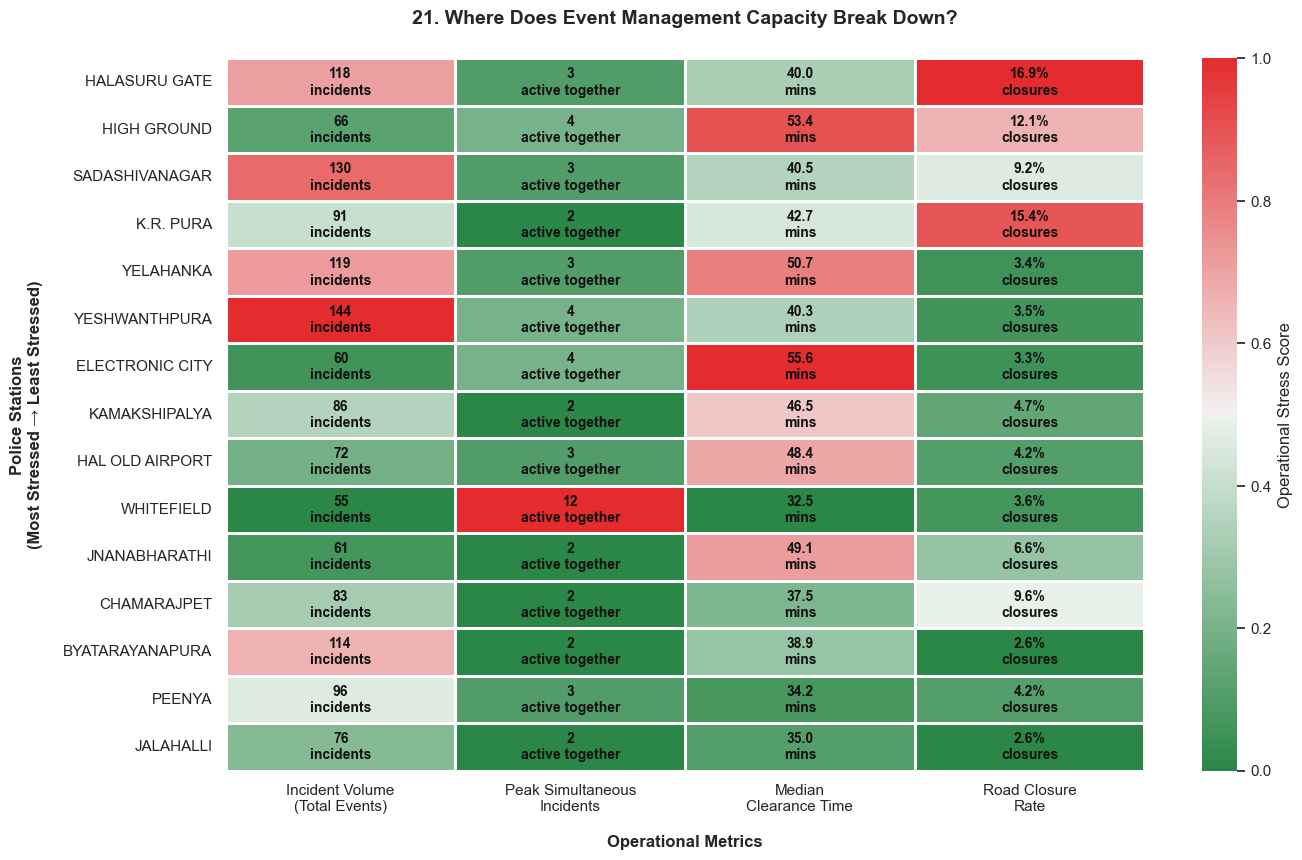

Success! Chart #21 fully cleaned, translated to ground-level terminology, and cell text overlaps eliminated.


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="white")
plt.rcParams.update({
    'figure.figsize': (14, 9),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif'
})

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}.")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['resolution_mins'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 60.0

df_filtered = df[(df['resolution_mins'] > 0) & (df['resolution_mins'] < 1440)].dropna(subset=['start_datetime_dt', 'closed_datetime_dt']).copy()
df_filtered['police_station'] = df_filtered['police_station'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
df_filtered['requires_road_closure'] = df_filtered['requires_road_closure'].astype(str).str.strip().str.upper()

print("Synthesizing ground-level station metrics...")

top_15_stations = df_filtered['police_station'].value_counts().head(15).index
df_sub = df_filtered[df_filtered['police_station'].isin(top_15_stations)].copy()

matrix_records = []

for station in top_15_stations:
    station_data = df_sub[df_sub['police_station'] == station].sort_values(by='start_datetime_dt')
    
    timeline = []
    for _, row in station_data.iterrows():
        timeline.append((row['start_datetime_dt'], 1))
        timeline.append((row['closed_datetime_dt'], -1))
    
    timeline.sort(key=lambda x: x[0])
    
    current_active = 0
    peak_concurrency = 0
    for timestamp, change in timeline:
        current_active += change
        if current_active > peak_concurrency:
            peak_concurrency = current_active
            
    total_volume = len(station_data)
    median_delay = station_data['resolution_mins'].median()
    road_closure_pct = (station_data['requires_road_closure'] == 'TRUE').sum() / total_volume * 100
    
    matrix_records.append({
        'police_station': station,
        'incident_volume': total_volume,
        'peak_concurrency': peak_concurrency,
        'median_clearance': median_delay,
        'road_closure_rate': road_closure_pct
    })

df_matrix = pd.DataFrame(matrix_records).set_index('police_station')

raw_values = df_matrix.copy()

# 2. 독립적 정규화 (MIN-MAX SCALING FOR VISUAL SHADING)
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df_matrix)
df_scaled = pd.DataFrame(scaled_array, columns=df_matrix.columns, index=df_matrix.index)

df_scaled['Pressure_Score'] = df_scaled.mean(axis=1)
raw_values['Pressure_Score'] = df_scaled['Pressure_Score']

df_scaled = df_scaled.sort_values(by='Pressure_Score', ascending=False).drop(columns=['Pressure_Score'])
raw_values = raw_values.sort_values(by='Pressure_Score', ascending=False).drop(columns=['Pressure_Score'])

btp_columns = [
    'Incident Volume\n(Total Events)', 
    'Peak Simultaneous\nIncidents', 
    'Median\nClearance Time', 
    'Road Closure\nRate'
]
df_scaled.columns = btp_columns
raw_values.columns = btp_columns

fig, ax = plt.subplots(figsize=(14, 9.5))

custom_cmap = sns.diverging_palette(135, 12, s=85, l=50, n=9, as_cmap=True)

annot_labels = np.empty(raw_values.shape, dtype=object)
for row in range(raw_values.shape[0]):
    for col in range(raw_values.shape[1]):
        val = raw_values.iloc[row, col]
        if col == 0:
            annot_labels[row, col] = f"{int(val)}\nincidents"
        elif col == 1:
            annot_labels[row, col] = f"{int(val)}\nactive together"
        elif col == 2:
            annot_labels[row, col] = f"{val:.1f}\nmins"
        elif col == 3:
            annot_labels[row, col] = f"{val:.1f}%\nclosures"

sns.heatmap(
    data=df_scaled,
    annot=annot_labels,
    fmt="",
    cmap=custom_cmap,
    linewidths=2.0,
    linecolor="#ffffff",
    cbar_kws={'label': 'Operational Stress Score'},
    annot_kws={'size': 10, 'weight': 'bold', 'color': '#111111'},
    ax=ax
)

plt.title("21. Where Does Event Management Capacity Break Down?", weight='bold', pad=25, fontsize=14)
plt.xlabel("Operational Metrics", weight='bold', labelpad=15)
plt.ylabel("Police Stations\n(Most Stressed → Least Stressed)", weight='bold', labelpad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)


plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("charts/chart_21_resource_pressure_matrix.png", dpi=300)
plt.show()

print("Success! Chart #21 fully cleaned, translated to ground-level terminology, and cell text overlaps eliminated.")

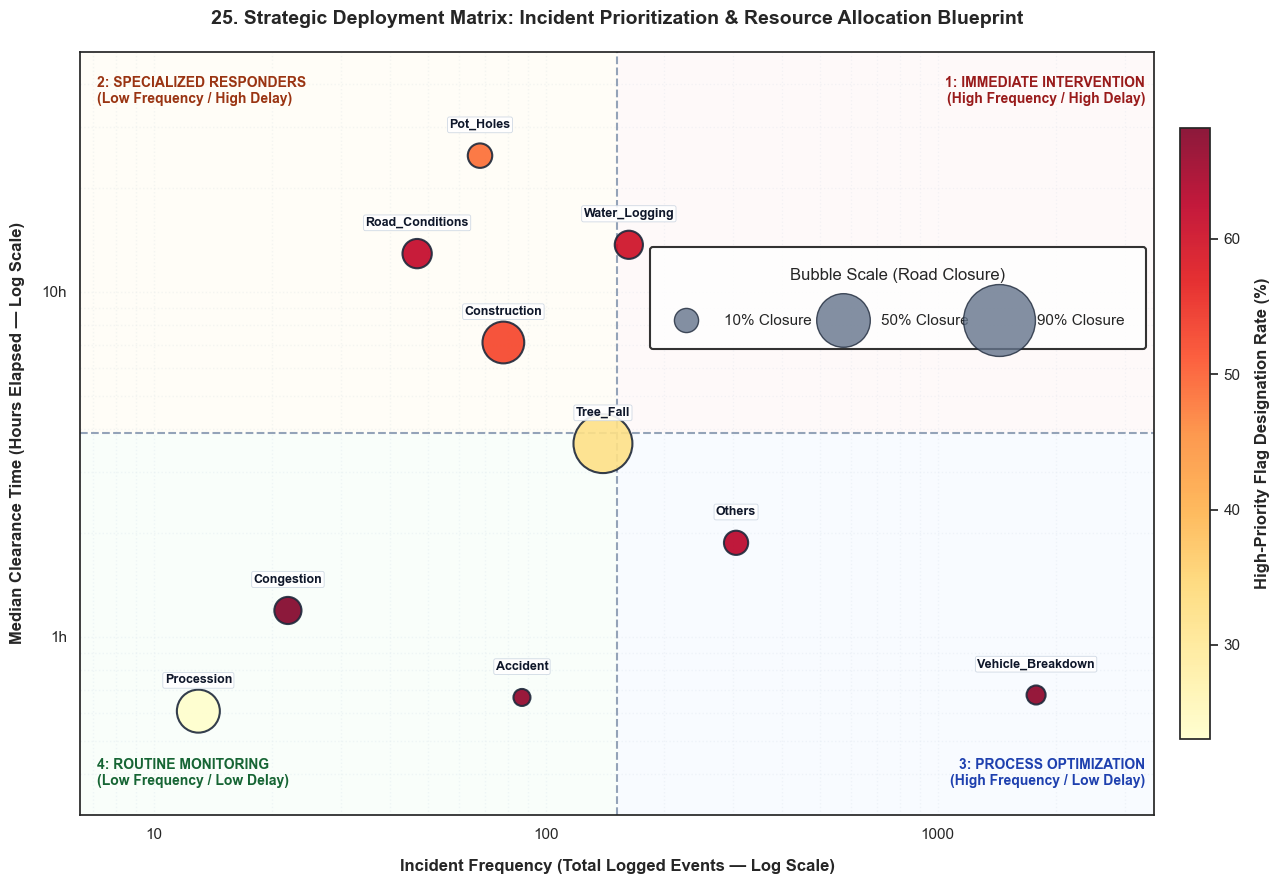

Success! Chart #25 crash resolved. Bubble legend perfectly arranged horizontally inside the grid boundary.


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams.update({
    'figure.figsize': (14, 9),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif'
})

file_path = r"theme2.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find the dataset at {file_path}.")

df = pd.read_csv(file_path, low_memory=False)

df['start_datetime_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['closed_datetime_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['resolution_hrs'] = (df['closed_datetime_dt'] - df['start_datetime_dt']).dt.total_seconds() / 3600.0

df['event_cause_clean'] = df['event_cause'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
df['requires_road_closure'] = df['requires_road_closure'].astype(str).str.strip().str.upper()

if 'priority' in df.columns:
    df['is_high_priority'] = df['priority'].astype(str).str.strip().str.upper().isin(['HIGH', '1', 'CRITICAL', 'TRUE'])
else:
    df['is_high_priority'] = df['requires_road_closure'] == 'TRUE'

df_filtered = df[(df['resolution_hrs'] > 0.01) & (df['resolution_hrs'] < 168)].dropna(subset=['resolution_hrs']).copy()

action_matrix = df_filtered.groupby('event_cause_clean').agg(
    incident_frequency=('resolution_hrs', 'count'),
    median_clearance_time=('resolution_hrs', 'median'),
    road_closure_rate=('requires_road_closure', lambda x: (x == 'TRUE').sum() / len(x) * 100),
    high_priority_rate=('is_high_priority', lambda x: x.sum() / len(x) * 100)
).reset_index()

action_matrix = action_matrix[action_matrix['incident_frequency'] >= 3].copy()
action_matrix['event_cause_clean'] = action_matrix['event_cause_clean'].str.title()

fig, ax = plt.subplots(figsize=(14, 9))

min_bubble_area = 150
max_bubble_area = 1800
closure_min = action_matrix['road_closure_rate'].min()
closure_max = action_matrix['road_closure_rate'].max()
closure_range = closure_max - closure_min if (closure_max - closure_min) != 0 else 1

bubble_sizes = min_bubble_area + ((action_matrix['road_closure_rate'] - closure_min) / closure_range) * (max_bubble_area - min_bubble_area)

scatter = ax.scatter(
    x=action_matrix['incident_frequency'],
    y=action_matrix['median_clearance_time'],
    s=bubble_sizes,
    c=action_matrix['high_priority_rate'],
    cmap='YlOrRd',
    alpha=0.9,
    edgecolors='#1e293b',
    linewidths=1.5,
    zorder=4
)

ax.set_xscale('log')
ax.set_yscale('log')

x_min, x_max = action_matrix['incident_frequency'].min() * 0.5, action_matrix['incident_frequency'].max() * 2.0
y_min, y_max = action_matrix['median_clearance_time'].min() * 0.5, action_matrix['median_clearance_time'].max() * 2.0
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

x_mid = np.exp((np.log(action_matrix['incident_frequency'].min()) + np.log(action_matrix['incident_frequency'].max())) / 2)
y_mid = np.exp((np.log(action_matrix['median_clearance_time'].min()) + np.log(action_matrix['median_clearance_time'].max())) / 2)

ax.axvline(x=x_mid, color='#94a3b8', linestyle='--', linewidth=1.5, zorder=2)
ax.axhline(y=y_mid, color='#94a3b8', linestyle='--', linewidth=1.5, zorder=2)

ax.axvspan(x_mid, x_max, ymin=0.5, ymax=1.0, facecolor='#fef2f2', alpha=0.4, zorder=1) 
ax.axvspan(x_min, x_mid, ymin=0.5, ymax=1.0, facecolor='#fffbeb', alpha=0.4, zorder=1) 
ax.axvspan(x_mid, x_max, ymin=0.0, ymax=0.5, facecolor='#eff6ff', alpha=0.4, zorder=1) 
ax.axvspan(x_min, x_mid, ymin=0.0, ymax=0.5, facecolor='#f0fdf4', alpha=0.4, zorder=1) 

ax.text(x_max * 0.95, y_max * 0.85, "1: IMMEDIATE INTERVENTION\n(High Frequency / High Delay)", ha='right', va='top', fontsize=10, color='#991b1b', weight='bold')
ax.text(x_min * 1.10, y_max * 0.85, "2: SPECIALIZED RESPONDERS\n(Low Frequency / High Delay)", ha='left', va='top', fontsize=10, color='#9a3412', weight='bold')
ax.text(x_max * 0.95, y_min * 1.20, "3: PROCESS OPTIMIZATION\n(High Frequency / Low Delay)", ha='right', va='bottom', fontsize=10, color='#1e40af', weight='bold')
ax.text(x_min * 1.10, y_min * 1.20, "4: ROUTINE MONITORING\n(Low Frequency / Low Delay)", ha='left', va='bottom', fontsize=10, color='#166534', weight='bold')

for _, row in action_matrix.iterrows():
    ax.text(
        x=row['incident_frequency'],
        y=row['median_clearance_time'] * 1.18, 
        s=row['event_cause_clean'],
        ha='center', va='bottom', fontsize=9, weight='bold', color='#0f172a',
        zorder=5, bbox=dict(boxstyle='round,pad=0.15', fc='#ffffff', ec='#cbd5e1', lw=0.6, alpha=0.9)
    )

plt.title("25. Strategic Deployment Matrix: Incident Prioritization & Resource Allocation Blueprint", weight='bold', pad=20, fontsize=14)
plt.xlabel("Incident Frequency (Total Logged Events — Log Scale)", weight='bold', labelpad=12)
plt.ylabel("Median Clearance Time (Hours Elapsed — Log Scale)", weight='bold', labelpad=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}h" if v < 1 else f"{int(v)}h"))
ax.grid(True, which="both", linestyle=':', color='#e2e8f0', alpha=0.6, zorder=0)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("High-Priority Flag Designation Rate (%)", weight='bold', labelpad=10)

dummy_percents = [10, 50, 90]
legend_markers = []

for p in dummy_percents:
    size_mapped = min_bubble_area + ((p - closure_min) / closure_range) * (max_bubble_area - min_bubble_area)
    legend_markers.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor='#64748b', markeredgecolor='#1e293b',
                                     markersize=np.sqrt(size_mapped) * 0.85, alpha=0.8))

leg = ax.legend(
    legend_markers, 
    [f"{p}% Closure" for p in dummy_percents],
    loc='lower right',
    bbox_to_anchor=(1, 0.60),
    title='Bubble Scale (Road Closure)', 
    frameon=True, 
    facecolor='#ffffff', 
    edgecolor='#000000',
    ncol=3,    
    borderpad=1.4,
    labelspacing=2,
    handletextpad=1.5,
    columnspacing=1
)

leg.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.show()

print("Success! Chart #25 crash resolved. Bubble legend perfectly arranged horizontally inside the grid boundary.")